# 40.11 Обработка ТТРКГ эксперимента 3

## Задача

Ноутбук строит диагностические ЭКГ-синхронизированные ансамбли канала 1
реокардиомонитора РНЦХ. В расчёт попадают только четыре основные записи из
паспорта `10.10–10.11`; `PULMOVISTA` и три неклассифицированные записи не
включаются.

Сигналы используются в заявленных прибором единицах без дополнительного gain,
offset или инверсии. Групповая задержка не измерена. Дыхательная и
ЭКГ-разметка эксперимента 3 имеет статус `pending_manual_review`; все численные
результаты этого ноутбука являются диагностическими.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from ttrkg_analysis import ensemble_waveform, robust_signal_metrics

REAL_MODE = os.environ.get("KALMYKOV_RUN_REAL", "0") == "1"
EXPLORATORY_MODE = os.environ.get("KALMYKOV_RUN_EXPLORATORY", "0") == "1"


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def status_allowed(status):
    return status == "accepted" or (EXPLORATORY_MODE and status == "pending_manual_review")


def discover_record_manifest(config, experiment_id, expected_pairs=None, expected_ids=None):
    spec = config.get("record_manifest", {})
    if spec.get("path") and Path(spec["path"]).is_file():
        path = Path(spec["path"]).expanduser().resolve()
        item = json.loads(path.read_text(encoding="utf-8"))
        if status_allowed(item.get("status")):
            return path, item
    if not EXPLORATORY_MODE:
        raise RuntimeError("Не задан принятый QC-манифест записей")
    derived_root = Path(config["derived_root"]).expanduser().resolve()
    matches = []
    required = {
        "record_id", "subject_id", "relative_path", "input_sha256",
        "actual_active_channels", "include", "qc_status", "configuration_id",
        "montage_id", "side_montage_id", "side_size_mm",
    }
    for path in sorted((derived_root / experiment_id / "qc").glob("*.json")):
        item = json.loads(path.read_text(encoding="utf-8"))
        rows = item.get("records", [])
        if not rows or not required.issubset(rows[0]):
            continue
        included = [row for row in rows if row.get("include") is True]
        ids = {row.get("record_id") for row in included}
        pairs = {(row.get("subject_id"), int(row["side_size_mm"])) for row in included if row.get("side_size_mm") is not None}
        if expected_ids is not None and ids != set(expected_ids):
            continue
        if expected_pairs is not None and pairs != set(expected_pairs):
            continue
        matches.append((path, item))
    if len(matches) != 1:
        raise RuntimeError(f"Ожидался один кандидатный QC-манифест, найдено {len(matches)}")
    return matches[0]


def load_sidecars(directory, annotation_type):
    result = {}
    for path in sorted(Path(directory).glob("*.json")):
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("annotation_type") != annotation_type:
            continue
        status = item.get("qc", {}).get("status")
        if not status_allowed(status):
            continue
        record_id = item.get("record_id")
        if not record_id or record_id in result:
            raise RuntimeError("Пустой или повторный record_id в разметке")
        result[record_id] = (path, item)
    return result


def breathing_modes(item):
    accepted = item.get("accepted_modes") or {}
    if item.get("qc", {}).get("status") == "accepted" and accepted:
        return {str(name): tuple(map(float, span)) for name, span in accepted.items()}, "accepted"
    if not EXPLORATORY_MODE:
        return {}, "unavailable"
    candidate = item.get("candidate_modes") or []
    if isinstance(candidate, dict):
        return {str(name): tuple(map(float, span)) for name, span in candidate.items()}, "pending_manual_review"
    modes = {
        str(row["mode"]): (float(row["start_s"]), float(row["stop_s"]))
        for row in candidate
        if {"mode", "start_s", "stop_s"}.issubset(row)
    }
    return modes, "pending_manual_review"


def ecg_peaks(item):
    status = item.get("qc", {}).get("status")
    if status == "accepted" and item.get("rpeaks_s"):
        return np.asarray(item["rpeaks_s"], dtype=float), "accepted"
    if EXPLORATORY_MODE and item.get("candidate_rpeaks_s"):
        return np.asarray(item["candidate_rpeaks_s"], dtype=float), "pending_manual_review"
    return np.asarray([], dtype=float), "unavailable"


def reported_ttrkg_operator(config):
    source = config.get("ttrkg_analysis", {})
    required = {"signal_column", "base_column", "unit_scale_to_ohm", "pre_s", "post_s", "grid_step_s", "baseline_s", "hold_margin_s"}
    if not required.issubset(source):
        raise RuntimeError("В ttrkg_analysis отсутствуют обязательные технические поля")
    scale = float(source["unit_scale_to_ohm"])
    if not np.isfinite(scale) or scale <= 0.0:
        raise ValueError("unit_scale_to_ohm должен быть положительным")
    delay = source.get("group_delay_s")
    delay_known = delay is not None and np.isfinite(float(delay))
    return {
        "signal_column": source["signal_column"],
        "base_column": source["base_column"],
        "unit_scale_to_ohm": scale,
        "sign": 1.0 if source.get("sign") is None else float(source["sign"]),
        "gain": 1.0 if source.get("gain") is None else float(source["gain"]),
        "base_sign": 1.0 if source.get("base_sign") is None else float(source["base_sign"]),
        "base_gain": 1.0 if source.get("base_gain") is None else float(source["base_gain"]),
        "base_offset_ohm": 0.0 if source.get("base_offset_ohm") is None else float(source["base_offset_ohm"]),
        "pre_s": float(source["pre_s"]),
        "post_s": float(source["post_s"]),
        "grid_step_s": float(source["grid_step_s"]),
        "baseline_s": tuple(map(float, source["baseline_s"])),
        "hold_margin_s": float(source["hold_margin_s"]),
        "group_delay_correction_s": float(delay) if delay_known else 0.0,
        "timing_status": "measured_and_corrected" if delay_known else "not_measured_not_corrected",
        "signal_policy": "instrument_reported_units_identity_transform",
    }


def annotation_quality(ecg_item, pulse_metrics):
    peaks, ecg_status = ecg_peaks(ecg_item)
    max_rr = float(np.max(np.diff(peaks))) if len(peaks) >= 2 else None
    warnings = []
    if ecg_status != "accepted":
        warnings.append("ЭКГ-разметка не принята вручную")
    if max_rr is not None and max_rr > 2.0:
        warnings.append("в кандидатной ЭКГ-разметке есть интервал более 2 с без R-зубца")
    if pulse_metrics["fraction_at_exact_extremes"] > 0.005:
        warnings.append("повторяются точные крайние уровни RHEO; причина не установлена")
    return peaks, ecg_status, max_rr, warnings


In [2]:
if not REAL_MODE:
    print("40.11: выполнена только структурная часть; для внешних данных задайте KALMYKOV_RUN_REAL=1")
else:
    config_path = Path(os.environ["KALMYKOV_EXP03_CONFIG"]).expanduser().resolve()
    config = json.loads(config_path.read_text(encoding="utf-8"))
    operator = reported_ttrkg_operator(config)
    expected_ids = {row["record_id"] for row in config["recordings"]}
    manifest_path, manifest = discover_record_manifest(config, "exp03", expected_ids=expected_ids)
    records = {row["record_id"]: row for row in manifest["records"] if row.get("include") is True}
    specs = {row["record_id"]: row for row in config["recordings"]}
    if set(records) != set(specs):
        raise RuntimeError("QC-манифест не совпадает с четырьмя основными записями эксперимента 3")

    data_root = Path(config["data_root"]).expanduser().resolve()
    csv_root = (data_root / config["csv_subdir"]).resolve()
    derived_root = Path(config["derived_root"]).expanduser().resolve()
    breathing = load_sidecars(derived_root / "exp03" / "annotations" / "breathing", "breathing")
    ecg = load_sidecars(derived_root / "exp03" / "annotations" / "ecg", "ecg")
    target_ids = {record_id for record_id, row in records.items() if 1 in row["actual_active_channels"] and specs[record_id]["role"] in {"ttrkg_channel_1_only", "both_channels_breathing"}}
    if not target_ids.issubset(ecg):
        raise RuntimeError("Для целевых записей отсутствует допустимая ЭКГ-разметка")

    canonical = ["time_s", "rheo_1_mohm", "base_1_ohm", "qs_1_ohm", "ecg_v", "rheo_2_mohm", "base_2_ohm", "qs_2_ohm"]
    raw_grid_s = np.arange(-operator["pre_s"], operator["post_s"] + 0.5 * operator["grid_step_s"], operator["grid_step_s"])
    reported_grid_s = raw_grid_s - operator["group_delay_correction_s"]
    outputs, failures, summary_rows = [], [], []
    for record_id in sorted(target_ids):
        record, spec = records[record_id], specs[record_id]
        ecg_path, ecg_item = ecg[record_id]
        source = (data_root / record["relative_path"]).resolve()
        source.relative_to(csv_root)
        if sha256_file(source) != record["input_sha256"] or ecg_item["input"]["sha256"] != record["input_sha256"]:
            raise RuntimeError("Исходный CSV или ЭКГ-разметка не совпали с QC-манифестом")
        frame = pd.read_csv(source)
        if list(frame.columns) != config["source_columns"]:
            raise RuntimeError("Схема CSV не совпала с конфигурацией")
        frame.columns = canonical
        time_s = frame["time_s"].to_numpy(float)
        pulse_ohm = operator["sign"] * operator["gain"] * operator["unit_scale_to_ohm"] * frame[operator["signal_column"]].to_numpy(float)
        base_ohm = operator["base_sign"] * operator["base_gain"] * frame[operator["base_column"]].to_numpy(float) + operator["base_offset_ohm"]
        pulse_metrics = robust_signal_metrics(pulse_ohm)
        rpeaks, ecg_status, max_rr_s, record_warnings = annotation_quality(ecg_item, pulse_metrics)
        if len(rpeaks) < 3:
            failures.append({"record_id": record_id, "mode": None, "reason": "менее трёх кандидатных R-зубцов"})
            continue
        if record_id in breathing:
            breath_path, breath_item = breathing[record_id]
            if breath_item["input"]["sha256"] != record["input_sha256"]:
                raise RuntimeError("Дыхательная разметка относится к другой версии CSV")
            modes, breath_status = breathing_modes(breath_item)
        else:
            breath_path, modes, breath_status = None, {}, "unavailable"
        if not modes:
            modes = {"неразделённая_запись_дыхательный_режим_не_установлен": (float(time_s[0]), float(time_s[-1]))}
            breath_status = "unavailable"
            record_warnings = record_warnings + ["дыхательный режим не восстановлен; используется только диагностический ансамбль всей записи"]
        state = "ttrkg_channel_1_only" if record["actual_active_channels"] == [1] else "ttrkg_channels_1_and_2_connected"
        for mode, (left, right) in modes.items():
            margin = operator["hold_margin_s"] if mode != "неразделённая_запись_дыхательный_режим_не_установлен" else 0.0
            interval = (left + margin, right - margin)
            mask = (time_s >= interval[0]) & (time_s <= interval[1])
            if mask.sum() < 10:
                failures.append({"record_id": record_id, "mode": mode, "reason": "слишком короткий интервал"})
                continue
            try:
                ensemble = ensemble_waveform(time_s, pulse_ohm, rpeaks, interval, raw_grid_s, operator["baseline_s"])
            except RuntimeError as error:
                failures.append({"record_id": record_id, "mode": mode, "reason": str(error)})
                continue
            baseline_z = float(np.median(base_ohm[mask]))
            mean = np.asarray(ensemble["mean"], dtype=float)
            se = np.asarray(ensemble["se_within_record"], dtype=float)
            recommendation = "только_диагностика_до_ручного_QC_разметки"
            outputs.append({
                "experiment_id": "exp03", "subject_id": record["subject_id"], "record_id": record_id,
                "role": spec["role"], "configuration_id": record["configuration_id"], "montage_id": record["montage_id"],
                "side_montage_id": record["side_montage_id"], "side_size_mm": record["side_size_mm"],
                "channel_state": state, "mode": mode, "time_from_detected_R_s": reported_grid_s.tolist(),
                "mean_delta_z_ohm": mean.tolist(), "se_within_record_ohm": se.tolist(), "baseline_z_ohm": baseline_z,
                "mean_fractional_delta_z": (mean / baseline_z).tolist() if baseline_z != 0.0 else None,
                "n_beats": ensemble["n_beats"], "n_rejected": ensemble["n_rejected"],
                "annotation_status": {"breathing": breath_status, "ecg": ecg_status}, "timing_status": operator["timing_status"],
                "recommendation": recommendation, "warnings": record_warnings, "input_sha256": record["input_sha256"],
                "ecg_sidecar_sha256": sha256_file(ecg_path), "breathing_sidecar_sha256": sha256_file(breath_path) if breath_path else None,
            })
            summary_rows.append({
                "роль_записи": spec["role"], "состояние_каналов": state, "режим": mode,
                "BASE1_Ом": baseline_z, "размах_ансамбля_мОм": 1000.0 * float(np.ptp(mean)),
                "циклы": ensemble["n_beats"], "отклонено": ensemble["n_rejected"], "max_RR_с": max_rr_s,
                "доля_крайних_RHEO1": pulse_metrics["fraction_at_exact_extremes"],
                "рекомендация": recommendation, "предупреждения": "; ".join(record_warnings) or "нет",
            })

    artifact = {
        "schema_version": 3, "analysis": "40.11_exp03_ttrkg_ensembles", "status": "exploratory_hypothesis_not_validated",
        "input_status": {"record_manifest": manifest.get("status")}, "signal_conversion": operator,
        "timing": {"status": operator["timing_status"], "applied_group_delay_s": operator["group_delay_correction_s"], "grid": "recorded_time_relative_to_detected_R"},
        "uncertainty_status": "within_record_se_only_not_total", "failures": failures, "ensembles": outputs,
        "config_sha256": sha256_file(config_path), "record_manifest_sha256": sha256_file(manifest_path),
    }
    out_dir = derived_root / "exp03" / "exploratory"
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "40.11_ttrkg_ensembles.exploratory.json").write_text(json.dumps(artifact, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    summary = pd.DataFrame(summary_rows)
    summary.to_csv(out_dir / "40.11_ttrkg_summary.exploratory.csv", index=False, encoding="utf-8-sig")
    print(f"40.11: рассчитано диагностических ансамблей={len(outputs)}, не рассчитано интервалов={len(failures)}, статус={artifact['status']}")
    display(summary.round({"BASE1_Ом": 4, "размах_ансамбля_мОм": 4, "max_RR_с": 3, "доля_крайних_RHEO1": 4}))
    if failures:
        display(pd.DataFrame(failures))


40.11: рассчитано диагностических ансамблей=5, не рассчитано интервалов=0, статус=exploratory_hypothesis_not_validated


,роль_записи,состояние_каналов,режим,BASE1_Ом,размах_ансамбля_мОм,циклы,отклонено,max_RR_с,доля_крайних_RHEO1,рекомендация,предупреждения
0,both_channels_breathing,ttrkg_channels_1_and_2_connected,спокойное_дыхание,54.412,245.0065,30,50,5.66,0.0001,только_диагностика_до_ручного_QC_разметки,ЭКГ-разметка не принята вручную; в кандидатной...
1,both_channels_breathing,ttrkg_channels_1_and_2_connected,вдох_и_задержка,58.129,178.1062,10,70,5.66,0.0001,только_диагностика_до_ручного_QC_разметки,ЭКГ-разметка не принята вручную; в кандидатной...
2,both_channels_breathing,ttrkg_channels_1_and_2_connected,форсированное_дыхание,54.441,162.4584,11,69,5.66,0.0001,только_диагностика_до_ручного_QC_разметки,ЭКГ-разметка не принята вручную; в кандидатной...
3,both_channels_breathing,ttrkg_channels_1_and_2_connected,задержка_на_выдохе,53.167,183.3850,20,60,5.66,0.0001,только_диагностика_до_ручного_QC_разметки,ЭКГ-разметка не принята вручную; в кандидатной...
4,ttrkg_channel_1_only,ttrkg_channel_1_only,неразделённая_запись_дыхательный_режим_не_уста...,101.353,91.8348,70,1,3.62,0.0322,только_диагностика_до_ручного_QC_разметки,ЭКГ-разметка не принята вручную; в кандидатной...


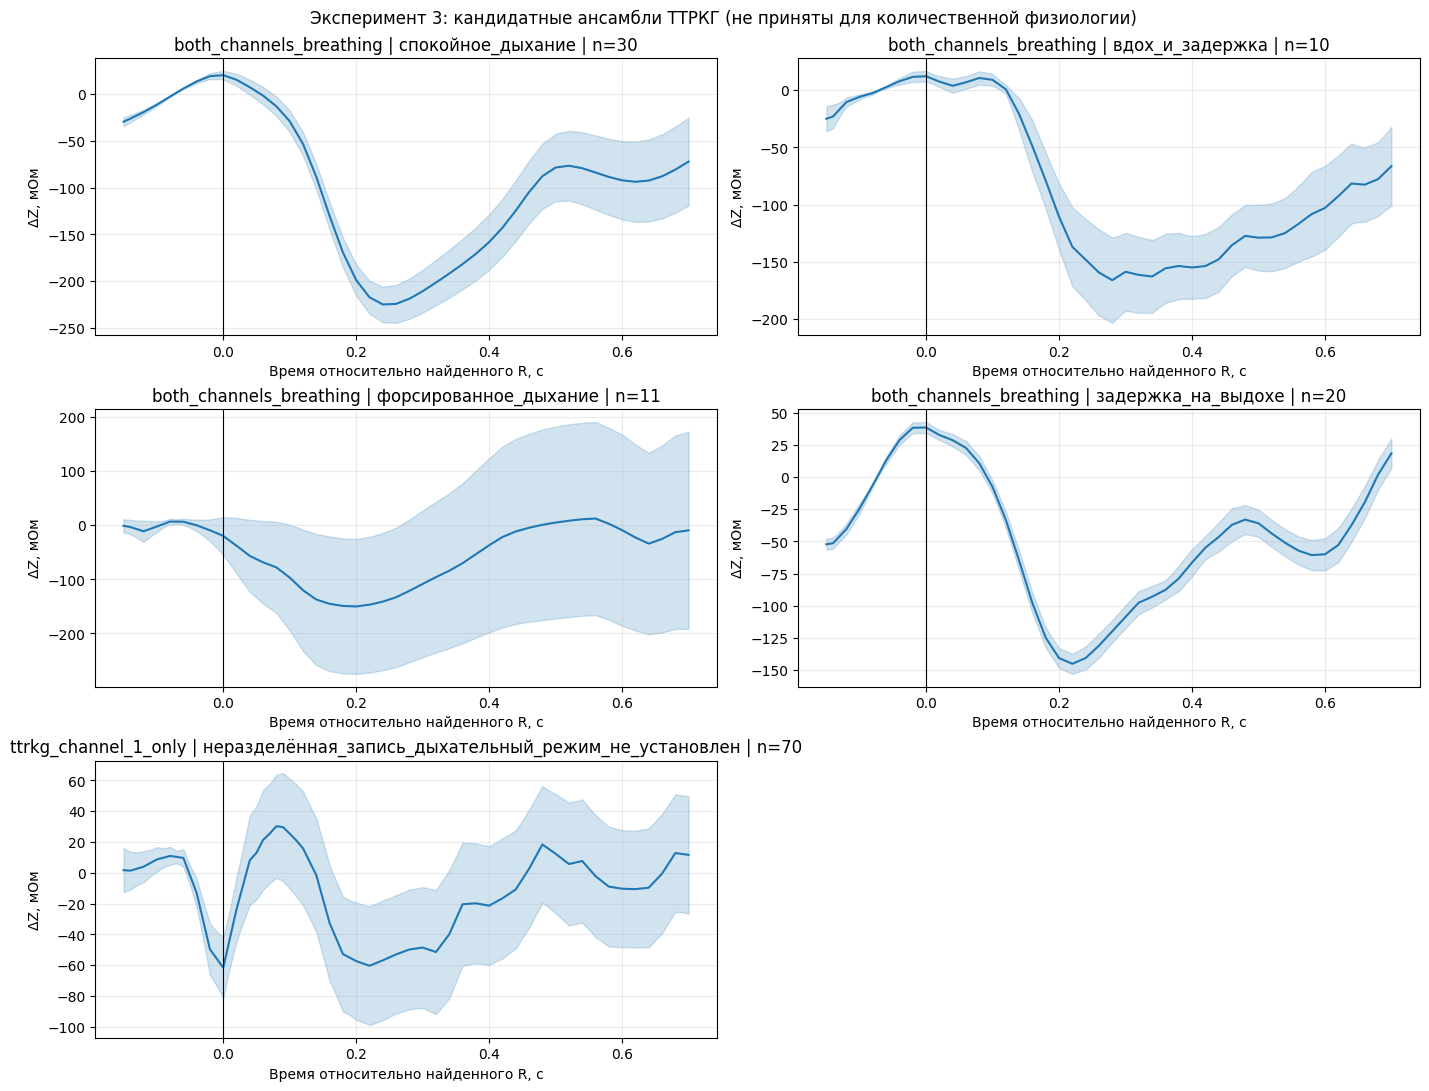

In [3]:
if REAL_MODE and outputs:
    n = len(outputs)
    columns = 2
    rows_count = int(np.ceil(n / columns))
    fig, axes = plt.subplots(rows_count, columns, figsize=(14, 3.6 * rows_count), squeeze=False, constrained_layout=True)
    for axis, row in zip(axes.flat, outputs):
        grid = np.asarray(row["time_from_detected_R_s"])
        mean = 1000.0 * np.asarray(row["mean_delta_z_ohm"])
        se = 1000.0 * np.asarray(row["se_within_record_ohm"])
        axis.plot(grid, mean, color="tab:blue")
        axis.fill_between(grid, mean - se, mean + se, color="tab:blue", alpha=0.2)
        axis.axvline(0.0, color="black", lw=0.8)
        axis.set(title=f"{row['role']} | {row['mode']} | n={row['n_beats']}", xlabel="Время относительно найденного R, с", ylabel="ΔZ, мОм")
        axis.grid(alpha=0.25)
    for axis in axes.flat[n:]:
        axis.axis("off")
    fig.suptitle("Эксперимент 3: кандидатные ансамбли ТТРКГ (не приняты для количественной физиологии)")
    fig.savefig(out_dir / "40.11_ttrkg_candidate_ensembles.png", dpi=160)
    plt.show()


## Граница результата

- Повторяемая форма после привязки к кандидатным R-зубцам сама по себе не
  доказывает сердечное происхождение сигнала.
- Длинные пропуски в ЭКГ-разметке и повторяющиеся крайние уровни `RHEO1`
  выводятся раздельно; причина крайних уровней не называется насыщением.
- Запись только канала 1 без восстановленного дыхательного протокола показана
  как единый диагностический ансамбль и не сравнивается количественно с
  задержками дыхания другой записи.
- Строгий выход `40.11` появится только после ручного принятия разметки и
  QC-манифеста.
